In [2]:
# =========================
# System / Utilities
# =========================
import os
import re
import tempfile
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")  # keep notebook output tidy

# =========================
# Data / Plotting
# =========================
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Data Access (optional)
# =========================
try:
    import yfinance as yf
except Exception:
    yf = None

try:
    from pandas_datareader import data as web
except Exception:
    web = None

# =========================
# ML: Models, Metrics, CV
# =========================
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from scipy.stats import pearsonr

# =========================
# Time-Series / Stats
# =========================
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# Imbalanced Data (optional)
# =========================
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

# =========================
# Explainability (optional)
# =========================
try:
    import shap
except Exception:
    shap = None

# =========================
# NLP: FinBERT (optional)
# =========================
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # reduce tokenizer thread warnings
try:
    import torch
    import torch.nn.functional as F
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
except Exception:
    torch = None
    F = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None

# =========================
# Scraping / PDF (optional)
# =========================
try:
    import requests
except Exception:
    requests = None

try:
    import pdfplumber
except Exception:
    pdfplumber = None

try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

# =========================
# Notebook display helpers
# =========================
from IPython.display import Markdown, display

In [2]:
# Claim all the folders used
project_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject"
scripts_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Scripts"
macro_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro"
beigebook_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
manual_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/manual"
model_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Models"
results_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Results"

In [3]:
# Read the CSV into a DataFrame
macro_fl_path = os.path.join(macro_directory, "macro_final_fl_df.csv")
macro_fl_df = pd.read_csv(macro_fl_path, index_col=0, parse_dates=True)

# Confirm successful load
print(macro_fl_df.info())
print(macro_fl_df.head(2))
print(macro_fl_df.tail(2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  SP500_TLT_Corr_24m_fl      248 non-null    float64
dtypes: float64(12)
memory usage: 25.2 KB
None
              CPI   INDPRO        VIX    T10Y

# Scrape Beige Books

### Initial Data Source Attempt and reCAPTCHA Restriction

The initial plan was to scrape historical Beige Book reports from the **Federal Reserve Bank of Minneapolis** website, which hosts an extensive archive dating back to **1970**. This source was ideal due to its consistent formatting and long historical coverage.

However, all automated requests were **blocked by Google’s reCAPTCHA** security protocol. Despite testing several workarounds including user-agent spoofing and time delays, no content could be reliably accessed or extracted using code-based methods.

As a result, I pivoted to the **official Federal Reserve website** ([federalreserve.gov](https://www.federalreserve.gov/)), which provides **PDF and HTML formats** of Beige Books from **1996 to present**. While this alternative required additional parsing logic (e.g., PDF/HTML parsing and chunking), it ensures **reliable and reproducible access** using public links.


## Main Source: The Federal Reserve (https://www.federalreserve.gov/) (1996 - Present)
Beige Book: https://www.federalreserve.gov/monetarypolicy/publications/beige-book-default.htm - (2025)  
Archive: https://www.federalreserve.gov/monetarypolicy/beige-book-archive.htm - (1996 - 2024)

### Sample URLs for Different Years
https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20170118.pdf  
https://www.federalreserve.gov/monetarypolicy/beigebook/files/Beigebook_20120606.pdf  
https://www.federalreserve.gov/monetarypolicy/beigebook/files/fullreport20120411.pdf  
https://www.federalreserve.gov/fomc/beigebook/2008/20081203/fullreport20081203.pdf  
https://www.federalreserve.gov/fomc/beigebook/2008/20080116/FullReport.htm  

https://www.federalreserve.gov/fomc/beigebook/2002/20020116/FullReport.htm  - Full Report  
https://www.federalreserve.gov/fomc/beigebook/2002/20020116/default.htm  - Summary  
https://www.federalreserve.gov/fomc/beigebook/2002/20020116/1.htm - First District - Boston  
https://www.federalreserve.gov/fomc/beigebook/2002/20020116/2.htm - Second District - New York

### Beige Book Publication Timing
	• The Beige Book is released eight times per year, roughly two weeks before each FOMC meeting.
	• Reports are usually published in mid to late months: January, March, May, July, September, October/November, and December.
	• However, it reflects conditions gathered in the prior 4–6 weeks, so the sentiment reflects economic activity from the month prior to publication.

# About This Publication

## What is the Beige Book?

The **Beige Book** is a Federal Reserve System publication released eight times per year that summarizes **current economic conditions** across the **12 Federal Reserve Districts**. It characterizes regional economic conditions and prospects based on a variety of mostly qualitative information gathered directly from each District's sources.

---

## What is the purpose of the Beige Book?

The purpose of the Beige Book is to describe changes in economic conditions since the last report. It is one of many ways the Federal Reserve engages with businesses and organizations to learn about economic developments in their communities. Because the information is collected from a wide range of contacts through various methods, it complements other forms of regional data gathering. The Beige Book is **not** a commentary on the views of Federal Reserve officials.

---

## How is the information collected?

Each Federal Reserve Bank collects information on current economic conditions in its District through reports from Bank and Branch directors, as well as interviews and online questionnaires completed by a diverse set of contacts, including businesses, community organizations, economists, and market experts. These sources are curated to provide accurate and objective information about a broad range of economic activities.

---

## How is the information used?

The information from the Beige Book supplements the data and analysis used by Federal Reserve economists and staff to assess economic conditions. The qualitative nature of the publication allows for the characterization of economic dynamics and the identification of emerging trends that may not be obvious in available economic data. This information also helps compare economic conditions across different parts of the country, which can be useful for assessing the outlook for the national economy.

---

## The Beige Book does not have the type of information I'm looking for. What other information is available?

The Federal Reserve System conducts a wide array of recurring surveys of businesses, households, and community organizations.

* A list of statistical releases compiled by the Federal Reserve Board is available [here](https://www.federalreserve.gov/feeds.htm).
* Links to each of the Federal Reserve Banks are available [here](https://www.federalreserve.gov/otherfrbs.htm).
* A summary of the System's community outreach is available [here](https://www.federalreserve.gov/communitydev/outreach-and-education.htm).

Additionally, the System holds "Fed Listens" events to hear how monetary policy affects people's lives and relies on various advisory councils with members from diverse backgrounds to gain perspectives on the economy.

---

**Note:** The Federal Reserve officially identifies Districts by number and Reserve Bank city. In the 12th District, the Seattle Branch serves Alaska, and the San Francisco Bank serves Hawaii. The System serves commonwealths and territories as follows: the New York Bank serves the Commonwealth of Puerto Rico and the U.S. Virgin Islands; the San Francisco Bank serves American Samoa, Guam, and the Commonwealth of the Northern Mariana Islands. The Board of Governors revised the branch boundaries of the System in February 1996.

In [8]:
# Define the dict of dates when the Beige Books are compiled
# https://www.federalreserve.gov/monetarypolicy/publications/beige-book-default.htm
release_dates = {
    #2025: ['1126', '1015', '0903', '0716', '0604', '0423', '0305', '0115'],
    2025: ['0716', '0604', '0423', '0305', '0115'],
    2024: ['1204', '1023', '0904', '0717', '0529', '0417', '0306', '0117'],
    2023: ['1129', '1018', '0906', '0712', '0531', '0419', '0308', '0118'],
    2022: ['1130', '1019', '0907', '0713', '0601', '0420', '0302', '0112'],
    2021: ['1201', '1020', '0908', '0714', '0602', '0414', '0303', '0113'],
    2020: ['1202', '1021', '0902', '0715', '0527', '0415', '0304', '0115'],
    2019: ['1127', '1016', '0904', '0717', '0605', '0417', '0306', '0116'],
    2018: ['1205', '1024', '0912', '0718', '0530', '0418', '0307', '0117'],
    2017: ['1129', '1018', '0906', '0712', '0531', '0419', '0301', '0118'],
    2016: ['1130', '1019', '0907', '0713', '0601', '0413', '0302', '0113'],
    2015: ['1202', '1014', '0902', '0715', '0603', '0415', '0304', '0114'],
    2014: ['1203', '1015', '0903', '0716', '0604', '0416', '0305', '0115'],
    2013: ['1204', '1016', '0904', '0717', '0605', '0417', '0306', '0116'],
    2012: ['1128', '1010', '0829', '0718', '0606', '0411', '0229', '0111'],
    2011: ['1130', '1019', '0907', '0727', '0608', '0413', '0302', '0112'],
    2010: ['1201', '1020', '0908', '0728', '0609', '0414', '0303', '0113'],
    2009: ['1202', '1021', '0909', '0729', '0610', '0415', '0304', '0114'],
    2008: ['1203', '1015', '0903', '0723', '0611', '0416', '0305', '0116'],
    2007: ['1128', '1017', '0905', '0725', '0613', '0425', '0307', '0117'],
    2006: ['1129', '1012', '0906', '0726', '0614', '0426', '0315', '0118'],
    2005: ['1130', '1019', '0907', '0727', '0615', '0420', '0309', '0119'],
    2004: ['1201', '1027', '0908', '0728', '0616', '0421', '0303', '0114'],
    2003: ['1126', '1015', '0730', '0611', '0423', '0305', '0115'],
    2002: ['1127', '1023', '0911', '0731', '0612', '0424', '0306', '0116'],
    # 2001: ['1128', '1024', '0919', '0808', '0613', '0502', '0307', '0117'],
    # 2000: ['1206', '1101', '0920', '0809', '0614', '0503', '0308', '0119'],
    # 1999: ['1208', '1103', '0922', '0811', '0616', '0505', '0317', '0120'],
    # 1998: ['1209', '1104', '0916', '0805', '0617', '0506', '0318', '0121'],
    # 1997: ['1203', '1029', '0917', '0806', '0618', '0507', '0312', '0122'],
    # 1996: ['1204', '1030'],
}

In [12]:
# downloaded_subfolder = os.path.join(beigebook_directory, "downloaded")
# os.makedirs(downloaded_subfolder, exist_ok=True) 

# # Determine URL based on year and format
# def get_beige_book_url(year, month_date):
#     """
#     Generates the correct Beige Book URL for a given year and release date.

#     Args:
#         year (int): The release year
#         month (str): The two-digit month (e.g., '07')
#         month_date (str): The full MMDD string (e.g., '0716')

#     Returns:
#         str: URL string to the report
#     """
#     # # Federal Reserve Bank of Boston
#     # if year >= 2024:
#     #     return f"https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_{year}{month_date}.pdf"
#     # elif 2023 >= year >= 2017:
#     #     return f"https://www.federalreserve.gov/monetarypolicy/beigebook{year}{month}.htm"
#     # # First District--Boston
#     # elif 2016 >= year >= 2011:
#     #     return f"https://www.federalreserve.gov/monetarypolicy/beigebook/beigebook{year}{month}.htm"
#     # elif 2010 >= year >= 2002:
#     #     return f"https://www.federalreserve.gov/fomc/beigebook/{year}/{year}{month_date}/FullReport.htm"
#     if year > 2016:
#         return f"https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_{year}{month_date}.pdf"
#     elif year in [2016, 2015, 2014, 2013] or (year == 2012 and month_date in ['1128', '1010', '0829', '0718', '0606']):
#         return f"https://www.federalreserve.gov/monetarypolicy/beigebook/files/Beigebook_{year}{month_date}.pdf"
#     elif (year == 2012 and month_date in ['0411', '0229', '0111']) or year == 2011:
#         return f"https://www.federalreserve.gov/monetarypolicy/beigebook/files/fullreport{year}{month_date}.pdf"
#     elif year in [2010, 2009] or (year == 2008 and month_date in ['1203', '1015', '0903', '0723', '0611', '0416', '0305']):
#         return f"https://www.federalreserve.gov/fomc/beigebook/{year}/{year}{month_date}/fullreport{year}{month_date}.pdf"
#     elif (year == 2008 and month_date == '0116') or (2007 >= year >= 2002):
#         return f"https://www.federalreserve.gov/fomc/beigebook/{year}/{year}{month_date}/FullReport.htm"
#     else:
#         return None

# # Download and extract/save text
# def download_and_save_text(pdf_url, save_path):
#     try:
#         print(f"Downloading: {pdf_url}")
#         response = requests.get(pdf_url, stream=True)
#         if response.status_code != 200:
#             print(f"Failed: HTTP {response.status_code}")
#             return False

#         if pdf_url.endswith(".pdf"):
#             with tempfile.NamedTemporaryFile(delete=False, suffix=".pdf") as tmp:
#                 tmp.write(response.content)
#                 temp_pdf_path = tmp.name

#             with pdfplumber.open(temp_pdf_path) as pdf:
#                 text = "\n".join([page.extract_text() or "" for page in pdf.pages])
#             os.remove(temp_pdf_path)

#         else:  # HTML fallback
#             text = response.text

#         with open(save_path, "w", encoding="utf-8") as f:
#             f.write(text)

#         print(f"Saved: {save_path}")
#         return True

#     except Exception as e:
#         print(f"Error downloading {pdf_url} — {e}")
#         return False

# # Main download logic
# if __name__ == "__main__":
#     failed_downloads = []
#     count = 0

#     for year, month_dates in release_dates.items():
#         for month_date in month_dates:
#             month = month_date[:2]
#             url = get_beige_book_url(year, month_date)
#             if not url:
#                 continue

#             file_name = f"{year}{month}.txt"
#             save_path = os.path.join(downloaded_subfolder, file_name)

#             success = download_and_save_text(url, save_path)
#             if success:
#                 count += 1
#             else:
#                 failed_downloads.append((year, month_date, url))

#     print(f"\nDownload complete. Total successful: {count}")
#     if failed_downloads:
#         print(f"\nFailed to download {len(failed_downloads)} reports:")
#         for year, month_date, url in failed_downloads:
#             print(f"  - {year}-{month_date}: {url}")
#     else:
#         print("No download failures.")

Downloading: https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20250716.pdf
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/202507.txt
Downloading: https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20250604.pdf
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/202506.txt
Downloading: https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20250423.pdf
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/202504.txt
Downloading: https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20250305.pdf
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/202503.txt
Downloading: https://www.federalreserve.gov/monetarypolicy/files/BeigeBook_20250115.pdf
Saved: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/202501.txt
Downloading: https://www.feder

In [23]:
# # Manual append the missing 2003 Sep Beige Book from Federal Reserve Archive: https://www.federalreserve.gov/monetarypolicy/beige-book-archive.htm 

# manual_downloaded_subfolder = os.path.join(manual_directory, "downloaded")
# os.makedirs(manual_downloaded_subfolder, exist_ok=True) 

# # Set your directory
# output_txt_path = os.path.join(manual_directory, "200309.txt")

# # Filter and sort files by leading number (district order)
# file_list = sorted(
#     [f for f in os.listdir(manual_downloaded_subfolder) if f.endswith(".pdf") and f[:2].isdigit()],
#     key=lambda x: int(x.split("_")[0])
# )

# # Combine text from all district PDFs
# combined_text = ""
# for file_name in file_list:
#     pdf_path = os.path.join(manual_downloaded_subfolder, file_name)
#     with pdfplumber.open(pdf_path) as pdf:
#         for page in pdf.pages:
#             text = page.extract_text()
#             if text:
#                 combined_text += text + "\n\n"

# # Save to single .txt file
# with open(output_txt_path, "w", encoding="utf-8") as f:
#     f.write(combined_text)

# print(f"Combined report saved to: {output_txt_path}")

Combined report saved to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/manual/200309.txt


In [25]:
# 12 District Codes
districts = [
    #"su",  # National Summary
    "bo",  # Boston
    "ny",  # New York
    "ph",  # Philadelphia
    "cl",  # Cleveland
    "ri",  # Richmond
    "at",  # Atlanta
    "ch",  # Chicago
    "sl",  # St. Louis
    "mi",  # Minneapolis
    "kc",  # Kansas City
    "da",  # Dallas
    "sf",  # San Francisco
]

In [29]:
# # Convert each distrct file into a txt file

# # Get district files only (starts with 01_ to 12_)
# pdf_files = sorted(
#     [f for f in os.listdir(manual_downloaded_subfolder)
#      if f.endswith(".pdf") and f[:2].isdigit() and f[:2] != "00"],
#     key=lambda x: int(x.split("_")[0])
# )

# # Loop and extract
# for file_name, district in zip(pdf_files, districts):
#     file_path = os.path.join(manual_downloaded_subfolder, file_name)
#     output_txt_name = f"200309_{district}.txt"
#     output_txt_path = os.path.join(manual_directory, output_txt_name)

#     print(f"Processing {file_name} → {output_txt_name}")

#     with pdfplumber.open(file_path) as pdf:
#         text = "\n".join([page.extract_text() or "" for page in pdf.pages])

#     with open(output_txt_path, "w", encoding="utf-8") as f:
#         f.write(text)

# print("All individual district files saved to:", manual_directory)

Processing 01_Boston_ September 2003.pdf → 200309_bo.txt
Processing 02_New York_ September 2003.pdf → 200309_ny.txt
Processing 03_Philadelphia_ September 2003.pdf → 200309_ph.txt
Processing 04_Cleveland_ September 2003.pdf → 200309_cl.txt
Processing 05_Richmond_ September 2003.pdf → 200309_ri.txt
Processing 06_Atlanta_ September 2003.pdf → 200309_at.txt
Processing 07_Chicago_ September 2003.pdf → 200309_ch.txt
Processing 08_St Louis_ September 2003.pdf → 200309_sl.txt
Processing 09_Minneapolis_ September 2003.pdf → 200309_mi.txt
Processing 10_Kansas City_ September 2003.pdf → 200309_kc.txt
Processing 11_Dallas_ September 2003.pdf → 200309_da.txt
Processing 12_San Francisco_ September 2003.pdf → 200309_sf.txt
All individual district files saved to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/manual


# Load, Clean, and Save Downloaded txt Files

In [40]:
beigebook_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
downloaded_subfolder = os.path.join(beigebook_directory, "downloaded")
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
os.makedirs(cleaned_subfolder, exist_ok=True)

In [42]:
# Initialize storage
records = []

# Iterate through all downloaded .txt files
for filename in sorted(os.listdir(downloaded_subfolder)):
    if filename.endswith(".txt") and len(filename) == 10:  # e.g., 200601.txt
        try:
            year = filename[:4]
            month = filename[4:6]
            date_str = f"{year}-{month}-01"
            
            file_path = os.path.join(downloaded_subfolder, filename)
            with open(file_path, "r", encoding="utf-8") as f:
                text = f.read().strip()

            # Optional: normalize whitespace (remove multiple newlines, etc.)
            cleaned_text = " ".join(text.split())

            records.append({
                "date": date_str,
                "content": cleaned_text
            })

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Create DataFrame
beige_book_df = pd.DataFrame(records)

# Save as CSV (or optionally parquet/pickle if large)
beige_book_output_path = os.path.join(cleaned_subfolder, "beige_books_full_report.csv")
beige_book_df.to_csv(beige_book_output_path, index=False)

print(f"Beige Book DataFrame saved to: {beige_book_output_path}")

Beige Book DataFrame saved to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/cleaned_full/beige_books_full_report.csv


In [44]:
print(beige_book_df.head(14))
print(beige_book_df.tail(14))

          date                                            content
0   2002-01-01  <html> <head> <title>FRB: Beige Book - Full re...
1   2002-03-01  <html> <head> <title>FRB: Beige Book - Full re...
2   2002-04-01  <html> <head> <title>FRB: Beige Book - Full re...
3   2002-06-01  <html> <head> <title>FRB: Beige Book - Full re...
4   2002-07-01  <html> <head> <title>FRB: Beige Book - Full re...
5   2002-09-01  <html> <head> <title>FRB: Beige Book - Full re...
6   2002-10-01  <html> <head> <title>FRB: Beige Book - Full re...
7   2002-11-01  <html> <head> <title>FRB: Beige Book - Full re...
8   2003-01-01  <html> <head> <title>FRB: Beige Book - Full re...
9   2003-03-01  <html> <head> <title>FRB: Beige Book - Full re...
10  2003-04-01  <html> <head> <title>FRB: Beige Book - Full re...
11  2003-06-01  <html> <head> <title>FRB: Beige Book - Full re...
12  2003-07-01  <html> <head> <title>FRB: Beige Book - Full re...
13  2003-09-01  Skip to main content Home National Summary: Se...
          

In [48]:
print(beige_book_df[['content']].iloc[0].to_string())

content    <html> <head> <title>FRB: Beige Book - Full re...


In [64]:
# Define output path
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
os.makedirs(cleaned_subfolder, exist_ok=True)
beige_book_output_path = os.path.join(cleaned_subfolder, "beige_books_full_report_cleaned.csv")

# Define cleaning function
def clean_for_finbert(text):
    # Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    # Remove lines that are mostly punctuation or formatting
    text = re.sub(r'\.{4,}', ' ', text)  # Replace long dot sequences with space
    text = re.sub(r'[_=*~•▪◦·]', ' ', text)  # Common formatting characters

    # Remove lines that are mostly repeated characters
    text = "\n".join([line for line in text.split("\n") if not re.fullmatch(r'[^A-Za-z0-9]{5,}', line)])

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
beige_book_df['cleaned_content'] = beige_book_df['content'].apply(clean_for_finbert)

# Save to CSV
beige_book_df[['date', 'content', 'cleaned_content']].to_csv(beige_book_output_path, index=False)

print(f"Cleaned CSV saved to: {beige_book_output_path}")

Cleaned CSV saved to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/cleaned_full/beige_books_full_report_cleaned.csv


## Reload the csv file into Data Frame

In [11]:
# Define output path
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
os.makedirs(cleaned_subfolder, exist_ok=True)
beige_book_output_path = os.path.join(cleaned_subfolder, "beige_books_full_report_cleaned.csv")

# Load into DataFrame
beige_book_df = pd.read_csv(beige_book_output_path)

print(beige_book_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             189 non-null    object
 1   content          189 non-null    object
 2   cleaned_content  189 non-null    object
dtypes: object(3)
memory usage: 4.6+ KB
None


In [33]:
# Preview first row
display(Markdown("**Original content (truncated):**"))
print(beige_book_df['content'].iloc[0][:2000], "\n")

display(Markdown("**Cleaned content (truncated):**"))
print(beige_book_df['cleaned_content'].iloc[0][:600])

**Original content (truncated):**

<html> <head> <title>FRB: Beige Book - Full report</title> <link rel="stylesheet" href="/assets/main.css" data-injected="worker-mf22nrg9"><script src="/assets/main.js" data-injected="worker-mf22nrg9" defer type="module"></script></head> <body bgcolor="#FFFFFF"><BASE TARGET="_top"> <a name="pagetop"></a> <a href="/"><img src="/gifjpg/sm_head2.gif" width=275 height=73 alt="The Federal Reserve Board eagle logo links to home page" border="0"></a> <hr noshade> <p> <table border=0 width = 600> <tr> <td valign=top> <a href="../../2002/" title="Link back to 2002 calendar"><img src="/gifjpg/Beige2.gif" width=80 height=95 border=0 alt="Beige Book logo links to Beige Book home page for year currently displayed"></a> </td> <td valign=top> <strong> <font size=+1>January 16, 2002</font> <p> <strong><font size=+2>Summary of Commentary on</font><br><font size=+3>Current Economic Conditions</font><br><font size=+2>by Federal Reserve District</font></strong> <p> </strong> </td> </tr> </table> <table bor

**Cleaned content (truncated):**

FRB: Beige Book - Full report January 16, 2002 Summary of Commentary onCurrent Economic Conditionsby Federal Reserve District Summary Prepared at the Federal Reserve Bank of Dallas and based on information collected before January 9, 2002. This document summarizes comments received from business and other contacts outside the Federal Reserve and is not a commentary on the views of Federal Reserve officials. Reports from the Federal Reserve Districts suggest that economic activity generally remained weak from late November through early January. But while there are still indications of caution,


In [19]:
# Preview last row
print("Original content (truncated):")
print(beige_book_df['content'].iloc[-1][:600], "\n")

print("Cleaned content  (truncated):")
print(beige_book_df['cleaned_content'].iloc[-1][:600])

Original content (truncated):
The Beige Book Summary of Commentary on Current Economic Conditions by Federal Reserve District July 2025 FEDERAL RESERVE SYSTEM i Contents About This Publication ....................................................................................................ii National Summary ...........................................................................................................1 Federal Reserve Bank of Boston ..................................................................................5 Federal Reserve Bank of New York ............................................................ 

Cleaned content  (truncated):
The Beige Book Summary of Commentary on Current Economic Conditions by Federal Reserve District July 2025 FEDERAL RESERVE SYSTEM i Contents About This Publication ii National Summary 1 Federal Reserve Bank of Boston 5 Federal Reserve Bank of New York 8 Federal Reserve Bank of Philadelphia 12 Federal Reserve Bank of Cleveland 16 Federal

In [70]:
for idx, row in beige_book_df.iterrows():
    if idx >= 5:
        break

    display(Markdown(f"### Date: `{row.get('date', 'N/A')}`"))
    display(Markdown(f"**Original (truncated):** `{row.get('content', '')[:250]}...`"))
    display(Markdown(f"**Cleaned:** `{row.get('cleaned_content', '')[:250]}...`"))
    print('-' * 80)

### Date: `2002-01-01`

**Original (truncated):** `<html> <head> <title>FRB: Beige Book - Full report</title> <link rel="stylesheet" href="/assets/main.css" data-injected="worker-mf22nrg9"><script src="/assets/main.js" data-injected="worker-mf22nrg9" defer type="module"></script></head> <body bgcolor...`

**Cleaned:** `FRB: Beige Book - Full report January 16, 2002 Summary of Commentary onCurrent Economic Conditionsby Federal Reserve District Summary Prepared at the Federal Reserve Bank of Dallas and based on information collected before January 9, 2002. This docum...`

--------------------------------------------------------------------------------


### Date: `2002-03-01`

...

--------------------------------------------------------------------------------


### Date: `2002-07-01`

**Original (truncated):** `<html> <head> <title>FRB: Beige Book - Full report</title> <link rel="stylesheet" href="/assets/main.css" data-injected="worker-mf22nr10"><script src="/assets/main.js" data-injected="worker-mf22nr10" defer type="module"></script></head> <body bgcolor...`

**Cleaned:** `FRB: Beige Book - Full report July 31, 2002 Summary of Commentary onCurrent Economic Conditionsby Federal Reserve District Summary Prepared at the Federal Reserve Bank of New York and based on information collected before July 23, 2002. This document...`

--------------------------------------------------------------------------------


In [74]:
print(beige_book_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             189 non-null    object
 1   content          189 non-null    object
 2   cleaned_content  189 non-null    object
dtypes: object(3)
memory usage: 4.6+ KB
None


In [35]:
print(beige_book_df.head(5))

         date                                            content  \
0  2002-01-01  <html> <head> <title>FRB: Beige Book - Full re...   
1  2002-03-01  <html> <head> <title>FRB: Beige Book - Full re...   
2  2002-04-01  <html> <head> <title>FRB: Beige Book - Full re...   
3  2002-06-01  <html> <head> <title>FRB: Beige Book - Full re...   
4  2002-07-01  <html> <head> <title>FRB: Beige Book - Full re...   

                                     cleaned_content  
0  FRB: Beige Book - Full report January 16, 2002...  
1  FRB: Beige Book - Full report March 6, 2002 Su...  
2  FRB: Beige Book - Full report April 24, 2002 S...  
3  FRB: Beige Book - Full report June 12, 2002 Su...  
4  FRB: Beige Book - Full report July 31, 2002 Su...  


In [83]:
# Add a new column with the character count of cleaned_content
beige_book_df['char_length'] = beige_book_df['cleaned_content'].str.len()

# Quick statistics summary
print(beige_book_df['char_length'].describe())

count       189.000000
mean     114456.010582
std       21406.537955
min       93638.000000
25%      104755.000000
50%      111461.000000
75%      115755.000000
max      262424.000000
Name: char_length, dtype: float64


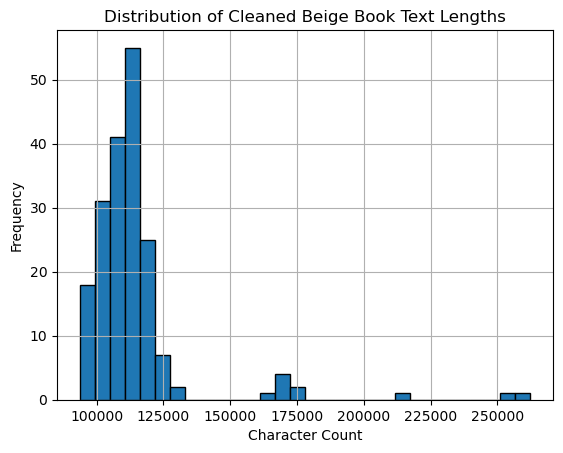

In [85]:
plt.hist(beige_book_df['char_length'], bins=30, edgecolor='black')
plt.title("Distribution of Cleaned Beige Book Text Lengths")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

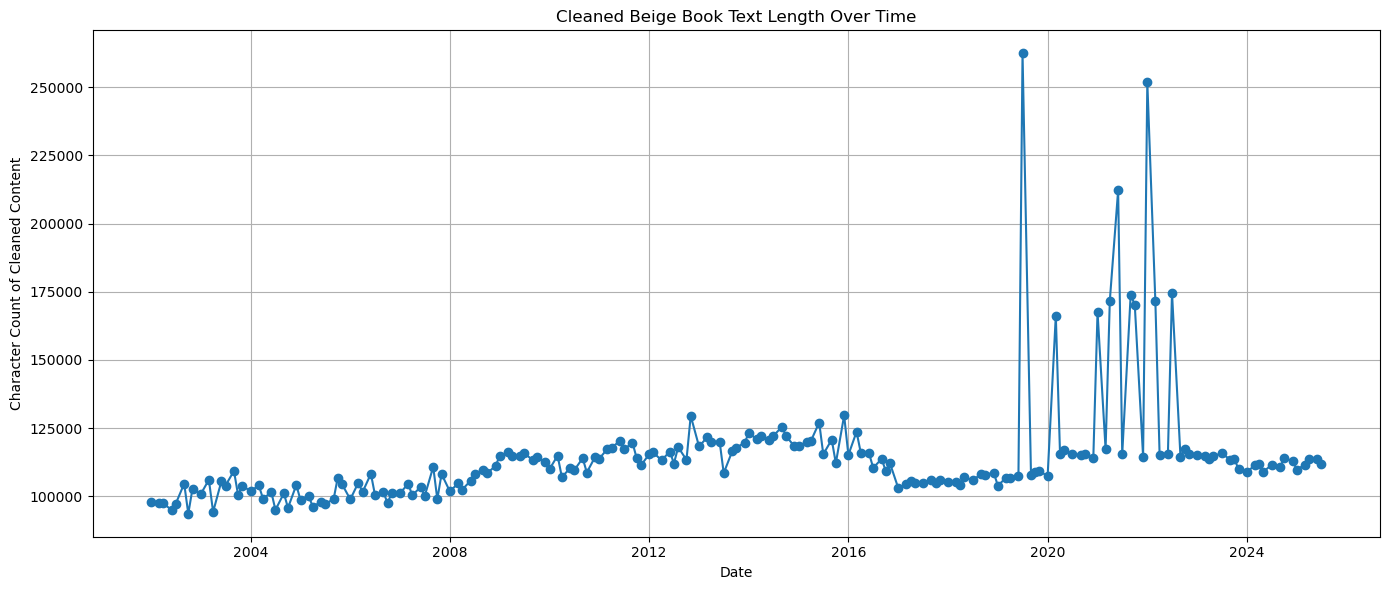

In [37]:
# Ensure 'date' is in datetime format
beige_book_df['date'] = pd.to_datetime(beige_book_df['date'])

# Compute character length if not already done
beige_book_df['char_length'] = beige_book_df['cleaned_content'].str.len()

# Sort by date for better visualization
beige_book_df = beige_book_df.sort_values('date')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(beige_book_df['date'], beige_book_df['char_length'], marker='o', linestyle='-')
plt.title("Cleaned Beige Book Text Length Over Time")
plt.xlabel("Date")
plt.ylabel("Character Count of Cleaned Content")
plt.grid(True)
plt.tight_layout()
plt.show()

## FinBERT Model Selection for Beige Book Sentiment Extraction

### Objective

The goal is to extract sentiment from **Federal Reserve Beige Book** reports (both full and district-level) to enhance forecasting models for **stock–bond correlations** during different economic regimes. This requires a **financial-domain-specific sentiment model** that can handle long and varied economic narratives.

---

### 🔍 FinBERT Model Options Reviewed

| Model Name                        | Label Order                        | Notes |
|----------------------------------|------------------------------------|-------|
| `ProsusAI/finbert`               | `['positive', 'negative', 'neutral']` | Optimized for production, stable, widely used |
| `yiyanghkust/finbert-tone`       | `['positive', 'neutral', 'negative']` | Academic variant, good for prototyping |
| `siebert/sentiment-roberta-large-english` | general-purpose                 | Large transformer, not finance-specific |

---

### Why Chose `ProsusAI/finbert`

- **Better for Production**: Maintained by Prosus AI, it’s more stable and production-ready.
- **Financial-Domain Tuned**: Specifically trained on the **Financial PhraseBank**, just like other FinBERTs, but optimized for real-world usage.
- **Label Order Compatibility**: Uses the intuitive `positive → negative → neutral` order, simplifying interpretation.
- **Robustness on Long Inputs**: Performs more consistently across longer passages (e.g., multi-page district summaries).
- **Community Adoption**: More commonly used in financial NLP workflows, with good documentation and support.

---

### Future Consideration

To further validate model performance, we may:
- Compare outputs across 20–30 manually labeled Beige Book excerpts
- Track model confidence scores (via softmax)
- Consider hybrid scoring (e.g., FinBERT + VADER for robustness)

---

# FinBERT
Best if:  
	•	Your text comes from the Beige Book (financial reports).  
	•	You need context-aware sentiment.  
	•	You are analyzing long-form structured text.  
	•	You don’t mind a slower but more accurate model.  

Avoid if:  
	•	Your dataset includes slang, sarcasm, or informal expressions.  

FinBERT, like most BERT-based models, can only handle up to 512 tokens at once. Your current pipeline processes the entire Beige Book as one long string, but when it exceeds 512 tokens, everything beyond the first 512 tokens is silently ignored. As Beige Books got longer over time, this means:  
	•	Only the intro is scored (which tends to be neutral or summary-like),  
	•	Later documents contribute less variation, producing flat, near-zero sentiment scores.  

# FinBERT Token Limit and Handling Long Beige Book Texts

## Problem: 512 Token Limit

FinBERT, like all BERT-based models, has a maximum input size of **512 tokens**.
This is a hard architectural constraint — any tokens beyond this limit are **ignored silently**.

### Implications:
- Only the **first few paragraphs** of the Beige Book are processed.
- These typically contain neutral summaries or boilerplate intros.
- The **detailed economic narratives**, where sentiment varies, are missed.
- As a result, **sentiment scores appear flat**, especially for longer documents.

---

## Solutions

### 1. **Sliding Window / Chunking**
Split each document into overlapping or non-overlapping **chunks of ≤512 tokens**:
- Use `tokenizer.encode()` to chunk by tokens
- Process each chunk separately
- Aggregate results (mean, weighted average, etc.)

### 2. **Paragraph-Level Sentiment**
Split by paragraph or sentence:
- Run FinBERT on each
- Aggregate (e.g., average sentiment per report)

### 3. **Selective Summarization (Optional)**
Use a separate summarizer model to condense the full text before scoring sentiment — but this may introduce bias or noise.

---

In [6]:
# Output path
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
os.makedirs(cleaned_subfolder, exist_ok=True)
beige_book_output_path = os.path.join(cleaned_subfolder, "beige_books_full_report_sentiment.csv")

In [8]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Enable GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"FinBERT model loaded on device: {device}")

FinBERT model loaded on device: cpu


In [9]:
# Sentiment scoring function using raw-text chunking
def sentiment_score_finbert_safe(text, max_len=512):
    """
    Splits text into chunks that FinBERT can process, aggregates sentiment.
    Returns average of probabilities for each sentiment class.
    """
    # Split raw text into words
    words = text.split()
    sentiment_scores = []

    for i in range(0, len(words), 400):  # ~400 words ≈ 512 tokens
        chunk = " ".join(words[i:i+400])
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True, max_length=max_len)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)
            sentiment_scores.append(probs[0].cpu().numpy())

    if sentiment_scores:
        avg_probs = np.mean(sentiment_scores, axis=0)
        return {
            'positive': float(avg_probs[0]),
            'negative': float(avg_probs[1]),
            'neutral':  float(avg_probs[2])
        }
    else:
        return {'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

# Compound score = Positive - Negative
def get_compound_score(sentiment_dict):
    return sentiment_dict['positive'] - sentiment_dict['negative']

In [1]:
# Define the path to your cleaned file
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
cleaned_csv_path = os.path.join(cleaned_subfolder, "beige_books_full_report_cleaned.csv")

# Load the DataFrame
beige_book_df = pd.read_csv(cleaned_csv_path, parse_dates=["date"])

# Confirm successful load
print(f"Loaded DataFrame with shape: {beige_book_df.shape}")
print(beige_book_df.info())
print(beige_book_df.head(2))

NameError: name 'os' is not defined

In [3]:
beige_book_df[['date', 'cleaned_content']].tail(5)

NameError: name 'beige_book_df' is not defined

In [ ]:
# Causes crash on long texts due to memory overload
# # Run scoring on cleaned Beige Book
# print("Running FinBERT sentiment scoring across all Beige Books...")
# beige_book_df['sentiment_dict'] = beige_book_df['cleaned_content'].apply(sentiment_score_finbert_safe)
# beige_book_df['sentiment'] = beige_book_df['sentiment_dict'].apply(get_compound_score)

In [3]:
# # Ensure tqdm works nicely in notebooks
# tqdm.pandas()

# # Prepare columns
# beige_book_df['sentiment_dict'] = None
# beige_book_df['sentiment'] = None

# # Loop row by row
# print("Running FinBERT sentiment scoring with memory-safe loop...")
# for i in tqdm(range(len(beige_book_df))):
#     text = beige_book_df.loc[i, 'cleaned_content']
    
#     try:
#         sentiment = sentiment_score_finbert_safe(text)
#         beige_book_df.at[i, 'sentiment_dict'] = sentiment
#         beige_book_df.at[i, 'sentiment'] = get_compound_score(sentiment)
#     except Exception as e:
#         print(f"Error on row {i}: {e}")
#         beige_book_df.at[i, 'sentiment_dict'] = {'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}
#         beige_book_df.at[i, 'sentiment'] = 0.0

#     # Explicit cleanup
#     gc.collect()

In [ ]:
# # Preview results
# print(beige_book_df[['date', 'sentiment', 'sentiment_dict']].head(3))
# print(beige_book_df[['date', 'sentiment', 'sentiment_dict']].tail(3))

In [ ]:
# # Save to CSV
# output_path = os.path.join(save_directory, 'sentiment_full_report.csv')
# beige_book_df[['date', 'sentiment', 'sentiment_dict']].to_csv(output_path, index=False)
# print(f"Sentiment scores saved to: {output_path}")

## Local FinBERT Execution Limitation

- Attempts to run **FinBERT** sentiment analysis locally in Jupyter caused **memory overload**, leading to crashes and kernel shutdown.  
- Transitioned to **Google Colab** for better memory handling.  
- Leveraged **GPU acceleration** in Colab, enabling faster and more stable inference.  

## Why Use Colab Instead of Local Notebook?  
### Local FinBERT Execution Limitation

Attempts to run FinBERT sentiment analysis locally in Jupyter failed due to:

- Long documents exceeding model token limits  
- **Memory overload**, causing crashes or kernel shutdown

To resolve this, I moved to **Google Colab**, which offers:

- Better memory management  
- GPU acceleration for faster inference  
- Safer execution on large text datasets

🔗 [Google Colab Notebook](https://colab.research.google.com/drive/17vWK156kMYjTq4POHrlgLt9wf-qqvFGm?usp=sharing)  
https://colab.research.google.com/drive/17vWK156kMYjTq4POHrlgLt9wf-qqvFGm?authuser=2#scrollTo=MZNOs0GnS087
https://drive.google.com/drive/u/2/folders/1irVywK6ob36hu848lpU6KnXh2XRgwlkG

## 1 Execution Pipeline on Google Colab (FinBERT Sentiment Extraction)

1. **Load Cleaned Beige Book Texts**  
   - Read from: `/content/drive/MyDrive/8588_Praxis/beige_books_full_report_cleaned.csv`

2. **Load FinBERT Model (`ProsusAI/finbert`)**  
   - Used Hugging Face `transformers` with GPU if available

3. **Apply Memory-Safe Sentiment Function**  
   - Tokenize each document and split into 512-token chunks  
   - Run FinBERT on each chunk and average softmax scores

4. **Calculate Sentiment Metrics**  
   - Extract full distribution: `positive`, `negative`, `neutral`  
   - Compute compound score: `positive - negative`

5. **Export Results to CSV**  
   - Saved as `/content/drive/MyDrive/8588_Praxis/beige_books_sentiment_scores.csv`  
   - Output includes: `date`, `sentiment`, `sentiment_dict`

This method provides a clear **directional sentiment measure**, helping models detect whether the tone leans positive or negative.

---

### Advantages of Using `positive − negative`

- **Captures Polarity**  
  - Positive values → more optimistic language  
  - Negative values → more pessimistic language  
  - Near zero → mixed or weak sentiment

- **Simple and Effective**  
  - Used in financial sentiment research and VADER-style sentiment scoring  
  - Avoids multicollinearity (since `positive + negative + neutral = 1`)

---

### Why `neutral` is Not Included

- Adds **redundant information** (not independent of other scores)  
- Often reflects lack of sentiment rather than direction  
- Can introduce **noise** or **overfitting** in models

---

### When to Include `neutral` (Optional)

You might retain the `neutral` column if you're doing:

- Exploratory sentiment analysis  
- Narrative density or tone complexity studies  
- Sentiment entropy or PCA

But for predictive modeling, it’s typically safe and preferred to **exclude `neutral`**.

---

### Final Recommendation

- Use only the `compound_score = positive − negative` as input for your baseline and forecasting models  
- Drop `sentiment_dict` columns unless needed for visualization or exploratory analysis

In [17]:
# Define the path to the sentiment file
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
sentiment_csv_path = os.path.join(cleaned_subfolder, "beige_books_sentiment_scores.csv")

# Load the DataFrame
beige_book_sentiment_df = pd.read_csv(sentiment_csv_path, parse_dates=["date"])

# Confirm successful load
print(f"Loaded DataFrame with shape: {beige_book_sentiment_df.shape}")
print(beige_book_sentiment_df.info())

Loaded DataFrame with shape: (189, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            189 non-null    datetime64[ns]
 1   sentiment       189 non-null    float64       
 2   sentiment_dict  189 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.6+ KB
None


In [19]:
pd.set_option('display.max_colwidth', None)
print(beige_book_sentiment_df.head(5))
print(beige_book_sentiment_df.tail(5))

        date  sentiment  \
0 2002-01-01  -0.878981   
1 2002-03-01  -0.801800   
2 2002-04-01  -0.550156   
3 2002-06-01  -0.588452   
4 2002-07-01  -0.541987   

                                                                                        sentiment_dict  
0  {'positive': 0.050907913595438004, 'negative': 0.9298890233039856, 'neutral': 0.019203081727027893}  
1   {'positive': 0.08812954276800156, 'negative': 0.8899292349815369, 'neutral': 0.021941175684332848}  
2    {'positive': 0.19870352745056152, 'negative': 0.7488590478897095, 'neutral': 0.05243739113211632}  
3   {'positive': 0.19183281064033508, 'negative': 0.7802851796150208, 'neutral': 0.027882032096385956}  
4   {'positive': 0.21363571286201477, 'negative': 0.7556225657463074, 'neutral': 0.030741801485419273}  
          date  sentiment  \
184 2025-01-01  -0.296162   
185 2025-03-01  -0.676239   
186 2025-04-01  -0.863769   
187 2025-06-01  -0.830174   
188 2025-07-01  -0.809508   

                                

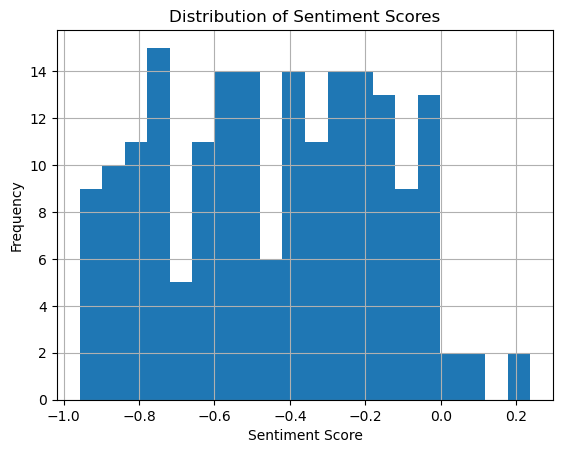

In [21]:
beige_book_sentiment_df['sentiment'].hist(bins=20)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## 2 Execution Pipeline on Google Colab (FinBERT Sentiment Extraction + SpaCy)

1. **Load Cleaned Beige Book Texts**  
   - Read from: `/content/drive/MyDrive/8588_Praxis/beige_books_full_report_cleaned.csv`

2. **Load FinBERT Model (`ProsusAI/finbert`)**  
   - Uses Hugging Face `transformers` library with GPU if available

3. **Apply Memory-Safe Sentiment Function**  
   - Tokenize each document using SpaCy  
   - Break text into sentences
   - Combine sentences until reaching a 512-token threshold  
   - Split into 512-token chunks for compatibility with FinBERT  
   - Run FinBERT on each chunk and average softmax scores

4. **Calculate Sentiment Metrics**  
   - Extract class probabilities: `positive`, `negative`, `neutral`  
   - Compute compound sentiment score as `positive - negative`

5. **Export Results to CSV**  
   - File saved to: `/content/drive/MyDrive/8588_Praxis/beige_books_sentiment_scores.csv`  
   - Output includes: `date`, `sentiment_spacy`, `sentiment_dict_spacy`

In [24]:
# Define the path to the sentiment file
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
sentiment_sentence_csv__path = os.path.join(cleaned_subfolder, "beige_books_sentiment_scores_spacy.csv")

# Load the DataFrame
beige_book_sentiment_sentence_df = pd.read_csv(sentiment_sentence_csv__path, parse_dates=["date"])

# Confirm successful load
print(f"Loaded DataFrame with shape: {beige_book_sentiment_sentence_df.shape}")
print(beige_book_sentiment_sentence_df.info())

Loaded DataFrame with shape: (189, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  189 non-null    datetime64[ns]
 1   sentiment_spacy       189 non-null    float64       
 2   sentiment_dict_spacy  189 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.6+ KB
None


In [26]:
pd.set_option('display.max_colwidth', None)
print(beige_book_sentiment_sentence_df.head(5))
print(beige_book_sentiment_sentence_df.tail(5))

        date  sentiment_spacy  \
0 2002-01-01        -0.859361   
1 2002-03-01        -0.688285   
2 2002-04-01        -0.494876   
3 2002-06-01        -0.575801   
4 2002-07-01        -0.675021   

                                                                                                  sentiment_dict_spacy  
0  {'positive_spacy': 0.05586167052388191, 'negative_spacy': 0.9152224063873291, 'neutral_spacy': 0.02891586907207966}  
1  {'positive_spacy': 0.1436631679534912, 'negative_spacy': 0.8319485187530518, 'neutral_spacy': 0.024388272315263748}  
2  {'positive_spacy': 0.23881955444812775, 'negative_spacy': 0.7336956858634949, 'neutral_spacy': 0.02748468704521656}  
3   {'positive_spacy': 0.195311039686203, 'negative_spacy': 0.7711122632026672, 'neutral_spacy': 0.033576685935258865}  
4  {'positive_spacy': 0.14765477180480957, 'negative_spacy': 0.8226759433746338, 'neutral_spacy': 0.02966933511197567}  
          date  sentiment_spacy  \
184 2025-01-01        -0.296113   
185 2

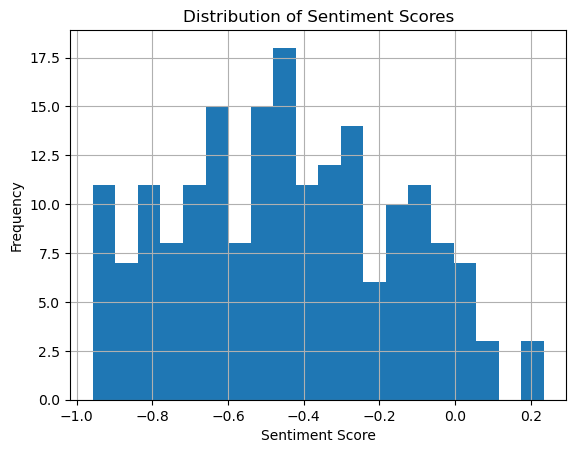

In [28]:
beige_book_sentiment_sentence_df['sentiment_spacy'].hist(bins=20)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

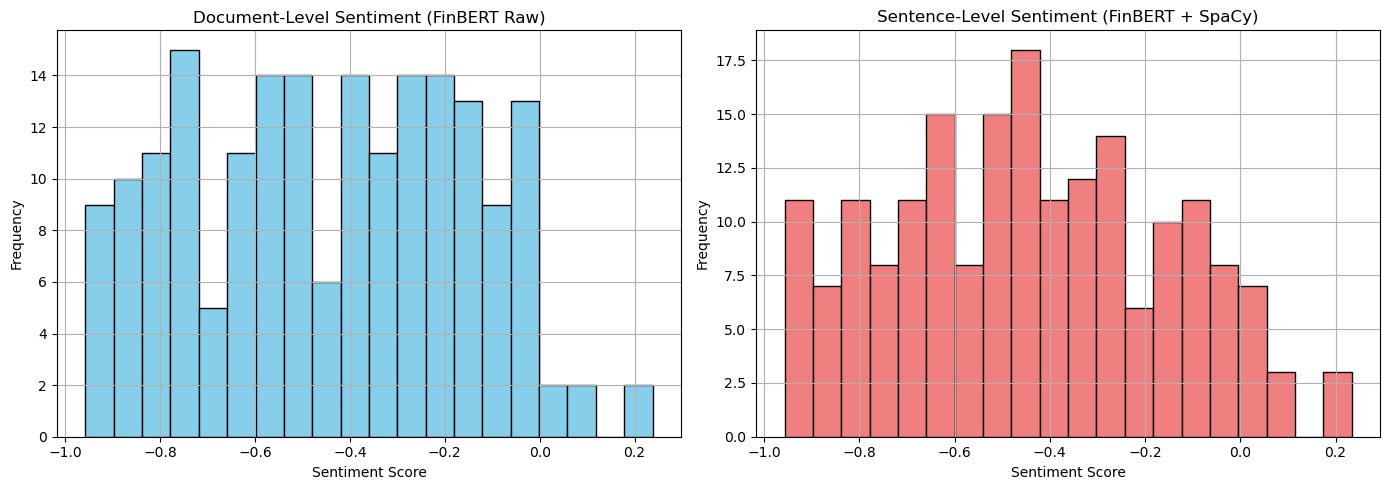

In [30]:
# Create a 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Document-level sentiment scores
axes[0].hist(beige_book_sentiment_df['sentiment'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("Document-Level Sentiment (FinBERT Raw)")
axes[0].set_xlabel("Sentiment Score")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# Plot 2: Sentence-level sentiment scores (Spacy-Aware)
axes[1].hist(beige_book_sentiment_sentence_df['sentiment_spacy'], bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title("Sentence-Level Sentiment (FinBERT + SpaCy)")
axes[1].set_xlabel("Sentiment Score")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

# Adjust layout and show both plots
plt.tight_layout()
plt.show()

## Combine sentiment scores into DF

In [32]:
# Drop the sentiment_dict columns if they exist
beige_book_sentiment_df = beige_book_sentiment_df.drop(columns=['sentiment_dict'], errors='ignore')
beige_book_sentiment_sentence_df = beige_book_sentiment_sentence_df.drop(columns=['sentiment_dict_spacy'], errors='ignore')

# Rename sentiment_spacy to sentiment_sentence
beige_book_sentiment_sentence_df = beige_book_sentiment_sentence_df.rename(columns={'sentiment_spacy': 'sentiment_sentence'})

# Merge on 'date' and retain 'sentiment' from the original
beige_book_combined_df = pd.merge(
    beige_book_sentiment_df[['date', 'sentiment']],  # Retain only relevant columns
    beige_book_sentiment_sentence_df[['date', 'sentiment_sentence']],
    on='date',
    how='inner'
)

# Preview
print(beige_book_combined_df.info())
print(beige_book_combined_df.head(5))
print(beige_book_combined_df.tail(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                189 non-null    datetime64[ns]
 1   sentiment           189 non-null    float64       
 2   sentiment_sentence  189 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 4.6 KB
None
        date  sentiment  sentiment_sentence
0 2002-01-01  -0.878981           -0.859361
1 2002-03-01  -0.801800           -0.688285
2 2002-04-01  -0.550156           -0.494876
3 2002-06-01  -0.588452           -0.575801
4 2002-07-01  -0.541987           -0.675021
          date  sentiment  sentiment_sentence
184 2025-01-01  -0.296162           -0.296113
185 2025-03-01  -0.676239           -0.652805
186 2025-04-01  -0.863769           -0.813283
187 2025-06-01  -0.830174           -0.780486
188 2025-07-01  -0.809508           -0.763256


# Sentiment Extraction (Beige Book)

- **FinBERT (Paragraph-level)**
  - Split text into 512-token chunks (FinBERT limit)  
  - Average chunk scores → stable overall sentiment  

- **spaCy + FinBERT (Sentence-level)**
  - Use spaCy to split into sentences  
  - Group sentences into ≤512 tokens → finer sentiment  

---

## Key Point
- **Paragraph-level (FinBERT)** = more stable, better for forecasting  
- **Sentence-level (spaCy + FinBERT)** = more detailed, but noisier  

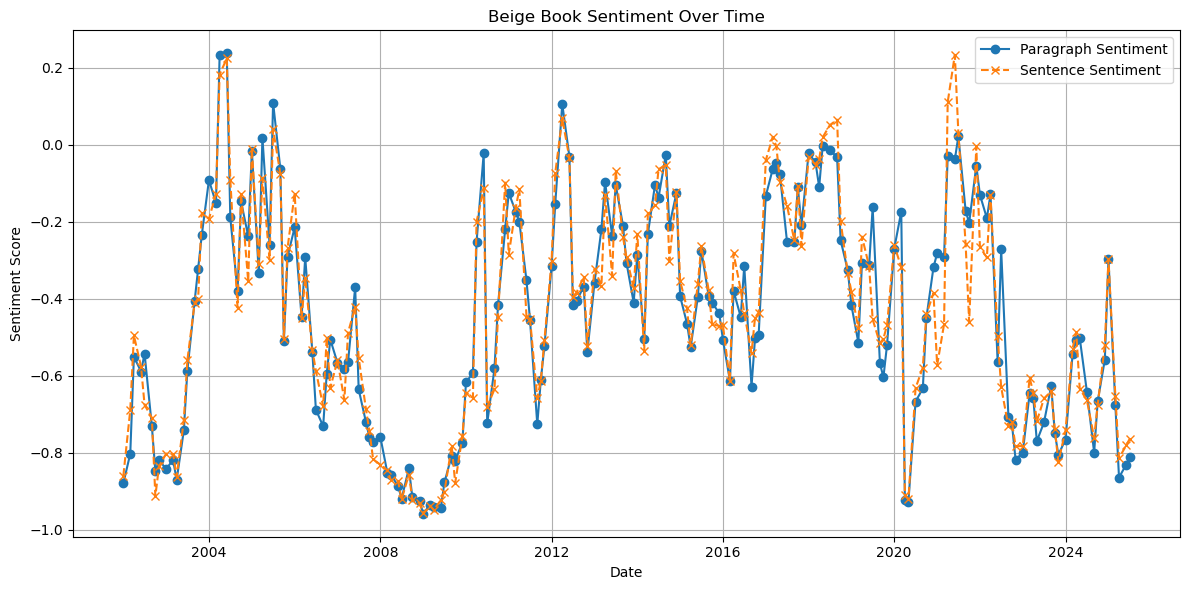

In [34]:
# --- Plot sentiment series ---
plt.figure(figsize=(12, 6))

plt.plot(
    beige_book_combined_df['date'],
    beige_book_combined_df['sentiment'],
    label="Paragraph Sentiment",
    marker='o',
    linestyle='-'
)

plt.plot(
    beige_book_combined_df['date'],
    beige_book_combined_df['sentiment_sentence'],
    label="Sentence Sentiment",
    marker='x',
    linestyle='--'
)

# --- Formatting ---
plt.title("Beige Book Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Load Baseline Dataset

In [9]:
# Read the CSV into a DataFrame
macro_fl_path = os.path.join(macro_directory, "macro_final_fl_df.csv")
macro_fl_df = pd.read_csv(macro_fl_path, index_col=0, parse_dates=True)

# Confirm successful load
print(macro_fl_df.info())
print(macro_fl_df.head(2))
print(macro_fl_df.tail(2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  SP500_TLT_Corr_24m_fl      248 non-null    float64
dtypes: float64(12)
memory usage: 25.2 KB
None
              CPI   INDPRO        VIX    T10Y

## Filling Missing Beige Book Sentiment for Monthly Alignment

The Beige Book is released 8 times per year, but our baseline dataset contains **monthly observations**. To align both datasets:

- We use **forward-fill imputation**, propagating the latest available sentiment score until the next Beige Book release.
- This mirrors real-world usage, where Beige Book insights are valid for months between releases.

**Steps:**
1. Merge baseline dataset with sentiment data on `date`.
2. Apply `.ffill()` on `sentiment` and `sentiment_sentence` columns.

This ensures that each month in the baseline has a valid sentiment input for modeling and forecasting.

In [28]:
# Merge macroeconomic features with sentiment data on 'date'
final_df = macro_fl_df.merge(
    beige_book_combined_df[['date', 'sentiment', 'sentiment_sentence']],
    on='date',
    how='left'
)

# Forward-fill missing sentiment scores to align with monthly data
final_df[['sentiment', 'sentiment_sentence']] = final_df[['sentiment', 'sentiment_sentence']].ffill()

In [30]:
# Preview
print(final_df.info())
print(final_df.head(5))
print(final_df.tail(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       248 non-null    datetime64[ns]
 1   CPI                        248 non-null    float64       
 2   INDPRO                     248 non-null    float64       
 3   VIX                        248 non-null    float64       
 4   T10YIE                     248 non-null    float64       
 5   GS10                       248 non-null    float64       
 6   SP500                      248 non-null    float64       
 7   TLT                        248 non-null    float64       
 8   Inflation_Uncertainty_10y  248 non-null    float64       
 9   Inflation_10y              248 non-null    float64       
 10  Real_Yield_10y             248 non-null    float64       
 11  INDPRO_YoY_Growth          248 non-null    float64       
 12  SP500_TL

## Lag Features for Beige Book Sentiment

### Why Create Lagged Sentiment Features?

- **Delayed Market Reaction**  
  Beige Book sentiment may take time to impact investor and economic behavior, so lagging helps model delayed effects.

- **Temporal Causality**  
  Lag features support capturing cause-effect relationships over time, essential in time series modeling.

- **Sparse Release Frequency**  
  Since Beige Book is only released **8 times per year**, lagged features help extend its predictive influence across all months.

---

### Derived Sentiment Features

| **Feature Name**        | **Description**                           |
|--------------------------|-------------------------------------------|
| `sentiment_lag_1m`      | Sentiment score from the previous month    |
| `sentiment_lag_3m`      | Sentiment score from 3 months ago          |
| `sentiment_rolling_avg_3m` | 3-month rolling average sentiment        |
| `sentiment_rolling_avg_6m` | 6-month rolling average sentiment        |
| `sentiment_diff_1m`     | Month-over-month sentiment change          |

These features can be created for both:
- `sentiment` (document-level FinBERT compound score)
- `sentiment_sentence` (sentence-level FinBERT + SpaCy compound score)
-  These derived features capture both **short-term lags** and **smoothed trends**, helping the model account for persistence, delayed effects, and shifts in sentiment.

In [79]:
for col in ['sentiment', 'sentiment_sentence']:
    final_df[f'{col}_lag_1m'] = final_df[col].shift(1)
    final_df[f'{col}_lag_3m'] = final_df[col].shift(3)
    final_df[f'{col}_rolling_avg_3m'] = final_df[col].rolling(window=3).mean()
    final_df[f'{col}_rolling_avg_6m'] = final_df[col].rolling(window=6).mean()
    final_df[f'{col}_diff_1m'] = final_df[col] - final_df[col].shift(1)

In [89]:
# Preview
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   date                               248 non-null    datetime64[ns]
 1   CPI                                248 non-null    float64       
 2   INDPRO                             248 non-null    float64       
 3   VIX                                248 non-null    float64       
 4   T10YIE                             248 non-null    float64       
 5   GS10                               248 non-null    float64       
 6   SP500                              248 non-null    float64       
 7   TLT                                248 non-null    float64       
 8   Inflation_Uncertainty_10y          248 non-null    float64       
 9   Inflation_10y                      248 non-null    float64       
 10  Real_Yield_10y                     248

In [91]:
print(final_df.head(5))
print(final_df.tail(5))

        date    CPI   INDPRO        VIX    T10YIE  GS10       SP500  \
0 2003-01-01  182.6  91.1369  27.424286  1.754286  4.05  855.700012   
1 2003-02-01  183.6  91.2505  32.218421  1.912632  3.90  841.150024   
2 2003-03-01  183.9  91.0006  30.634286  1.862857  3.81  848.179993   
3 2003-04-01  183.2  90.4311  23.991905  1.774762  3.96  916.919983   
4 2003-05-01  182.9  90.4000  20.239524  1.660952  3.57  963.590027   

         TLT  Inflation_Uncertainty_10y  Inflation_10y  ...  sentiment_lag_1m  \
0  41.223919                   0.006598       0.024890  ...               NaN   
1  42.500748                   0.006590       0.025235  ...         -0.841032   
2  41.920738                   0.006590       0.025259  ...         -0.841032   
3  42.360195                   0.006570       0.024511  ...         -0.818666   
4  45.037216                   0.006560       0.024059  ...         -0.869220   

   sentiment_lag_3m  sentiment_rolling_avg_3m  sentiment_rolling_avg_6m  \
0          

## Save the final dataset into CSV

In [86]:
# Define the path to the fainl file
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
final_df_csv_path = os.path.join(cleaned_subfolder, "final_df.csv")

# Ensure the directory exists
os.makedirs(cleaned_subfolder, exist_ok=True)

# Save DataFrame to the defined path
final_df.to_csv(final_df_csv_path, index=False)

print(f"✅ Saved final_df to:\nFolder: {cleaned_subfolder}\nFile: {final_df_csv_path}")

✅ Saved final_df to:
Folder: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/cleaned_full
File: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook/cleaned_full/final_df.csv


Here’s the full summary converted into Jupyter Notebook Markdown syntax, suitable for documentation or exploratory analysis:

⸻

📊 Validating Beige Book Sentiment Scores (FinBERT)

After extracting sentiment scores from the Beige Book reports using FinBERT, it’s important to validate these scores before using them in forecasting models. This ensures the extracted signals are meaningful, robust, and improve model accuracy.

⸻

✅ 1. Visual Inspection Over Time

plt.figure(figsize=(14, 5))
plt.plot(beige_book_df['date'], beige_book_df['sentiment'], label='Compound Sentiment Score')
plt.title('Beige Book Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.grid(True)
plt.legend()
plt.show()

Inspect whether sentiment dips during known economic crises (e.g., 2008, 2020) and rises during expansion periods. A flat line could suggest truncation effects from FinBERT’s 512-token limit.

⸻

✅ 2. Comparison Against Macroeconomic Indicators

Overlay sentiment trends with:
	•	VIX (Volatility Index)
	•	Unemployment rate
	•	CPI / Inflation
	•	GDP growth
	•	Fed interest rate policy

Use rolling averages if needed:

beige_book_df['sentiment_rolling'] = beige_book_df['sentiment'].rolling(3).mean()

Helps assess alignment between FinBERT sentiment and broader economic activity.

⸻

✅ 3. Granger Causality Test

Test if sentiment scores predict macro targets.

from statsmodels.tsa.stattools import grangercausalitytests

# Assuming merged_df contains both sentiment and a macro series like 'vix_change'
grangercausalitytests(merged_df[['vix_change', 'sentiment']], maxlag=3)

If p < 0.05, sentiment could be used for forecasting that macro variable.

⸻

✅ 4. Ablation Test (With vs. Without Sentiment)

Compare forecasting performance:
	•	Baseline model (no sentiment)
	•	Sentiment-enhanced model

Evaluate with RMSE, MAE, or Sharpe Ratio. Example:

baseline_rmse = mean_squared_error(y_true, baseline_preds, squared=False)
enhanced_rmse = mean_squared_error(y_true, sentiment_model_preds, squared=False)

A meaningful drop in error confirms sentiment adds predictive power.

⸻

✅ 5. Feature Importance (SHAP / Permutation)

Evaluate if sentiment features are consistently ranked important.

import shap
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values)

If sentiment consistently contributes to predictions, it validates its utility.

⸻

✅ Conclusion

While you’re ready to use sentiment in modeling, validation ensures trustworthiness and interpretability. Include visual, statistical, and comparative checks to confirm FinBERT’s effectiveness before final integration into your two-stage forecasting framework.

Let me know if you’d like to extend validation with regression-based attribution, LIME, or PCA diagnostics.

In [35]:
print(districts)

['bo', 'ny', 'ph', 'cl', 'ri', 'at', 'ch', 'sl', 'mi', 'kc', 'da', 'sf']


# Split by Distict for deep analyze on the sentiment
2017 - Current  
Federal Reserve Bank of Boston  
Federal Reserve Bank of New York  
Federal Reserve Bank of Philadelphia  
Federal Reserve Bank of Cleveland  
Federal Reserve Bank of Richmond  
Federal Reserve Bank of Atlanta  
Federal Reserve Bank of Chicago  
Federal Reserve Bank of St. Louis  
Federal Reserve Bank of Minneapolis  
Federal Reserve Bank of Kansas City  
Federal Reserve Bank of Dallas  
Federal Reserve Bank of San Francisco  

2002 - 2016  
First District--Boston  

# Not in use due to URLs are protected by Google reCAPTCHA
## Alaternative Source: The Federal Reserve Bank of Minneapolis (1970 - Present)
Archive: https://www.minneapolisfed.org/region-and-community/regional-economic-indicators/beige-book-archive

### Sample URLs for Different Years
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-su - Beige Book: National Summary  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-bo - Beige Book Report: Boston  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-ny - Beige Book Report: New York  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-ph - Beige Book Report: Philadelphia  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-cl - Beige Book Report: Cleveland  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-ri - Beige Book Report: Richmond  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-at - Beige Book Report: Atlanta  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-ch - Beige Book Report: Chicago  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-sl - Beige Book Report: St Louis  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-mi - Beige Book Report: Minneapolis  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-kc - Beige Book Report: Kansas City  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-da - Beige Book Report: Dallas  
https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-sf - Beige Book Report: San Francisco  


https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-su - Beige Book: National Summary  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-bo - Beige Book Report: Boston  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-ny - Beige Book Report: New York  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-ph - Beige Book Report: Philadelphia  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-cl - Beige Book Report: Cleveland  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-ri - Beige Book Report: Richmond  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-at - Beige Book Report: Atlanta  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-ch - Beige Book Report: Chicago  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-sl - Beige Book Report: St Louis  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-mi - Beige Book Report: Minneapolis  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-kc - Beige Book Report: Kansas City  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-da - Beige Book Report: Dallas  
https://www.minneapolisfed.org/beige-book-reports/2002/2002-01-sf - Beige Book Report: San Francisco  

In [ ]:
# # Beige Book release months
# release_dates = {
#     #2025: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2025: ['07', '06', '04', '03', '01'],
#     2024: ['12', '10', '09', '07', '05', '04', '03', '01'],
#     2023: ['11', '10', '09', '07', '05', '04', '03', '01'],
#     2022: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2021: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2020: ['12', '10', '09', '07', '05', '04', '03', '01'],
#     2019: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2018: ['12', '10', '09', '07', '05', '04', '03', '01'],
#     2017: ['11', '10', '09', '07', '05', '04', '03', '01'],
#     2016: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2015: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2014: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2013: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2012: ['11', '10', '08', '07', '06', '04', '02', '01'],
#     2011: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2010: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2009: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2008: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2007: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2006: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2005: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2004: ['12', '10', '09', '07', '06', '04', '03', '01'],
#     2003: ['11', '10', '09', '07', '06', '04', '03', '01'],
#     2002: ['11', '10', '09', '07', '06', '04', '03', '01'],
# }

In [ ]:
# # 13 District Codes
# districts = [
#     "su",  # National Summary
#     "bo",  # Boston
#     "ny",  # New York
#     "ph",  # Philadelphia
#     "cl",  # Cleveland
#     "ri",  # Richmond
#     "at",  # Atlanta
#     "ch",  # Chicago
#     "sl",  # St. Louis
#     "mi",  # Minneapolis
#     "kc",  # Kansas City
#     "da",  # Dallas
#     "sf",  # San Francisco
# ]

In [ ]:
# # URL generation
# def generate_beige_book_urls(base_url="https://www.minneapolisfed.org/beige-book-reports"):
#     url_list = []

#     for year, months in release_dates.items():
#         for month in months:
#             yyyymm = f"{year}-{month}"
#             for region in districts:
#                 full_url = f"{base_url}/{year}/{yyyymm}-{region}"
#                 url_list.append({
#                     "date": yyyymm,
#                     "region": region,
#                     "url": full_url
#                 })

#     return pd.DataFrame(url_list)

# # Create dataframe
# urls_df = generate_beige_book_urls()

In [ ]:
# # Showing the result
# print(f"Total URLs: {len(urls_df)}")

# print(urls_df.head(14).to_string(index=False))

# print(urls_df.tail(14).to_string(index=False))

In [ ]:
# from selenium import webdriver
# from selenium.webdriver.chrome.options import Options
# import time
# import os

# # Parameters
# url = "https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-su"
# save_path = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
# filename = os.path.join(save_path, "2025-07-su.txt")
# os.makedirs(save_path, exist_ok=True)

# # Configure headless browser
# options = Options()
# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
# driver = webdriver.Chrome(options=options)

# try:
#     # Step 1: Load outer page
#     driver.get(url)
#     time.sleep(3)

#     # Step 2: Locate iframe and extract src
#     iframe = driver.find_element("tag name", "iframe")
#     inner_url = iframe.get_attribute("src")
    
#     # Step 3: Load the iframe src directly
#     driver.get(inner_url)
#     time.sleep(3)

#     # Step 4: Get full visible text
#     content = driver.find_element("tag name", "body").text

#     # Step 5: Save content
#     with open(filename, "w", encoding="utf-8") as f:
#         f.write(content)

#     print(f"✅ File saved: {filename}")

# except Exception as e:
#     print(f"❌ Error: {e}")

# finally:
#     driver.quit()

## Blocker Summary: reCAPTCHA-Protected Beige Book Pages

### Problem Description
The URLs you're trying to access for Beige Book reports, such as: https://www.minneapolisfed.org/beige-book-reports/2025/2025-07-su are protected by **Google reCAPTCHA**. These pages **embed their main content in a dynamic subpage** (e.g., `report-detail/` route), which cannot be accessed or scraped by automated scripts.

### Why This Fails in Code
- Scripts (e.g., `requests`, `urllib`, or even `Selenium`) **get blocked or redirected**.
- Returned pages contain only:
  - `"Privacy – Terms"` text
  - Empty HTML shells
- No report body or text is ever downloaded.
- Resulting `.txt` files are empty.

### Error Messages You May See
- `No content extracted.`
- `Check the page manually.`
- `Privacy - Terms` inside downloaded files

### Workable Alternatives
1. **Manual Copy-Paste**  
   Open the report in a browser and copy the content into `.txt` files manually.

2. **Community Archive (Recommended)**  
   Use this community archive instead:  
   [GitHub - BeigeBook](https://github.com/JonathanStroud/BeigeBook)  
   Includes full Beige Book texts from 2000–2022 in `.txt` format.

3. **PDFs from FederalReserve.gov**  
   Some reports are available as PDFs from:
   - [https://www.federalreserve.gov/monetarypolicy/beigebook2025.htm](https://www.federalreserve.gov/monetarypolicy/beigebook2025.htm)

---

### Summary
Automated scripts are **blocked by anti-bot protection**. A manual or alternative source approach is required for text extraction.